In [1]:
# !pip install thop
# !pip install torchsummary
#!pip install einops
#!pip install -q kaggle
#!pip install torch
#!pip install numpy
#!pip install opencv-python
#!pip install matplotlib
#!pip install natsort
#!pip install torchvision

In [2]:
import numpy as np
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
from glob import glob

import torch
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F

from thop import profile
from torchsummary import summary
import io
import random

In [ ]:
import subprocess
if torch.cuda.is_available():
    device = torch.device("cuda")
    result = torch.cuda.get_device_name(torch.cuda.current_device())
elif torch.backends.mps.is_available():
    device = "mps"
    
    result = subprocess.run(["system_profiler", "SPHardwareDataType"], capture_output=True, text=True)
    
    chip_info = [line for line in result.stdout.split("\n") if "Chip" in line]
    memory_info = [line for line in result.stdout.split("\n") if "Memory" in line]
    
    gpu_result = subprocess.run(["system_profiler", "SPDisplaysDataType"], capture_output=True, text=True)
    
    gpu_info_lines = gpu_result.stdout.split("\n")
    gpu_chip_info = next((line for line in gpu_info_lines if "Chipset Model" in line), "GPU model info not found")
    gpu_cores = next((line for line in gpu_info_lines if "Total Number of Cores" in line), "GPU cores info not found")
    
    chip_info = chip_info[0] if chip_info else "Chip info not found"
    memory_info = memory_info[0] if memory_info else "Memory info not found"
    gpu_info = f"{gpu_chip_info}, {gpu_cores}"

else:
    device = "cpu"
    chip_info = "MPS not available, using CPU"
    memory_info = "N/A"
    gpu_info = "N/A"

if device == torch.device("cuda"):
    print(f"Current device: {result}")
elif device == "mps":
    print(f"Current device: {chip_info}")
    print(f"Memory Info: {memory_info}")
    print(f"GPU Info: {gpu_info}")
else:
    print("Current device: CPU")

if device == torch.device("cuda"):
    torch.cuda.empty_cache()
if device == "mps":
    torch.mps.empty_cache()

Current device: NVIDIA GeForce RTX 4060 Ti


# Dataloader

In [ ]:
config = {
    "sequence_length": 50,
    "batch_size": 512,
    "hidden_size": 128,
    "n_layers": 3,
    "learning_rate": 0.001,
    "n_epochs": 50,
    "device": device,
    "n_prime_text" : 10,
}

In [5]:
class TextDataset(Dataset):
    def __init__(self, text_data, sequence_length):
        self.text_data = text_data
        self.sequence_length = sequence_length
        
    def __len__(self):
        return len(self.text_data) - self.sequence_length
        
    def __getitem__(self, idx):
        x = self.text_data[idx:idx + self.sequence_length]
        y = self.text_data[idx + 1:idx + self.sequence_length + 1]
        return torch.LongTensor(x), torch.LongTensor(y)


In [6]:
data_URL = "./shakespeare_train.txt"
with io.open(data_URL, 'r', encoding='utf8') as f:
 train_text = f.read()

data_URL = "./shakespeare_valid.txt"
with io.open(data_URL, 'r', encoding='utf8') as f:
 val_text = f.read()
 
# Characters' collection
vocab = set(train_text)
# Construct character dictionary
vocab_to_int = {c: i for i, c in enumerate(vocab)}
int_to_vocab = dict(enumerate(vocab))
# Encode data, shape = [number of characters]
train_data = np.array([vocab_to_int[c] for c in train_text], dtype=np.int32)

train_dataset = TextDataset(train_data, config['sequence_length'])
train_dl = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
for_predict = next(iter(train_dl))
for_predict_words, _ = for_predict

# Encode data, shape = [number of characters]
valid_data = np.array([vocab_to_int[c] for c in val_text], dtype=np.int32)

valid_dataset = TextDataset(valid_data, config['sequence_length'])
valid_dl = DataLoader(valid_dataset, batch_size=config['batch_size'], shuffle=True)

print("valid dataset length: ", len(valid_dl))
print("train data Length: ", len(train_data))
print("Train dataset length: ", len(train_dl))
print("vocab size: ", len(vocab))

valid dataset length:  434
train data Length:  4351312
Train dataset length:  8499
vocab size:  67


# Model

+ Model Specifications:
  + Input: **`[B, 3, 32, 32]`**
  + Output: **`[B, 10]`**

In [ ]:
class RNNmodel(nn.Module):
    def __init__(self, input_size = len(vocab), hidden_size = config['hidden_size'], output_size = len(vocab), n_layers = config['n_layers']):
        super(RNNmodel, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded, hidden)
        output = output.contiguous().view(-1, self.hidden_size)
        output = self.fc(output)
        return output, hidden
    
    def init_hidden(self, batch_size):
        return torch.zeros(self.n_layers, batch_size, self.hidden_size).to(config['device'])


rnn_model = RNNmodel().to(config["device"])

In [8]:
class LSTMmodel(nn.Module):
    def __init__(self, input_size = len(vocab), hidden_size = config['hidden_size'], output_size = len(vocab), n_layers = config['n_layers']):
        super(LSTMmodel, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        embedded = self.embedding(x)
        output, hidden = self.lstm(embedded, hidden)
        output = output.contiguous().view(-1, self.hidden_size)
        output = self.fc(output)
        return output, hidden
    
    def init_hidden(self, batch_size):
        return (torch.zeros(self.n_layers, batch_size, self.hidden_size).to(config['device']),
                torch.zeros(self.n_layers, batch_size, self.hidden_size).to(config['device']))

lstm_model = LSTMmodel().to(config["device"])


In [9]:
def generate_text(model, prime_text, vocab_to_int, int_to_vocab, 
                 predict_len, temperature=0.8):
    model.eval()
    hidden = model.init_hidden(1)
    prime_input = torch.LongTensor([vocab_to_int[char] for char in prime_text]).to(config['device'])
    predicted_text = prime_text
    
    # use prime text to initialize hidden state
    for p in range(len(prime_text) - 1):
        _, hidden = model(prime_input[p].view(1, 1), hidden)
    
    last_char = prime_input[-1]
    
    for i in range(predict_len):
        output, hidden = model(last_char.view(1, 1), hidden)
        output_dist = output.data.view(-1).div(temperature).exp()
        top_char = torch.multinomial(output_dist, 1)[0]
        predicted_char = int_to_vocab[top_char.item()]
        predicted_text += predicted_char
        last_char = top_char
    
    return predicted_text

# Training

In [10]:
criterion = nn.CrossEntropyLoss()

In [11]:
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=config['learning_rate'], weight_decay=1e-3)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = len(train_dl.dataset) / config['batch_size'] * config["n_epochs"], eta_min = 0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',           
    factor=0.7,           
    patience=1,
    threshold=0.0001,     
    threshold_mode='rel',
    min_lr=0.0001,        
)
print(len(train_dl.dataset) / config['batch_size'])

8498.55859375


In [12]:
# weight_path = 'rnn_model.pt'

# checkpoint = torch.load(weight_path)
# rnn_model.load_state_dict(checkpoint, strict=True)

In [13]:
def train_model(model, train_loader, val_loader, model_type="RNN"):
    valid_loss_min = np.inf
    history = []
    
    for epoch in range(config['n_epochs']):
        lrs = []
        batch_bpc = []
        batch_err = []
        train_loss = 0.0
        train_err = 0
        val_loss = 0.0
        val_err = 0
        result = {'batch_train_bpc': [], 'train_bpc': [], 'val_bpc': [], 'lrs': [], 'batch_train_err': [] , 'train_err': [], 'val_err': []}
        
        model.train()
        # hidden = model.init_hidden(config['batch_size'])
        batch_cnt = 0
        for batch in tqdm(train_loader):
            (inputs, targets) = batch
            inputs, targets = inputs.to(config['device']), targets.to(config['device'])
            
            hidden = model.init_hidden(inputs.size(0))

            if model_type == "LSTM":
                hidden = tuple([h.detach() for h in hidden])
            else:
                hidden = hidden.detach()
                
            model.zero_grad()
            output, hidden = model(inputs, hidden)
            # output, hidden = model(inputs, hidden, targets)
            # output = output.view(-1, output.size(-1))  # (batch_size * seq_len, output_size)
            loss = criterion(output, targets.view(-1))
            ans = torch.argmax(output, dim=1)
            # train_err += (ans != targets.view(-1)).sum().item() / config['batch_size']
            train_err += (ans != targets.view(-1)).sum().item() / (config['sequence_length'] * config['batch_size'])
            batch_bpc.append((loss / torch.log(torch.tensor(2.0))).item())
            batch_err.append((ans != targets.view(-1)).sum().item() / (config['sequence_length'] * config['batch_size']))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
            optimizer.step()
            # scheduler.step(loss)
            # if batch_cnt > 0:
                # if optimizer.param_groups[0]['lr'] != lrs[-1]:
                #     print(f"Loss is NOT decreased more than {scheduler.patience} times, lr: {lrs[-1]} -> {optimizer.param_groups[0]['lr']}")
            lrs.append(optimizer.param_groups[0]['lr'])
            
            
            train_loss += loss.item()
            if batch_cnt == 0 and epoch == 0:
                model.eval()
                prime_text = ''.join([int_to_vocab[idx.item()] for idx in for_predict_words[0][:config['n_prime_text']]])
                print("lr: ", lrs[-1])
                print("BPC: ", batch_bpc[-1])
                print(f"Error: {batch_err[-1] * 100} %")
                print("Prime text: ")
                print(prime_text)
                print("------------\nTarget: ")
                print(''.join([int_to_vocab[idx.item()] for idx in for_predict_words[0]]))
                print("------------\nPrediction: ")
                
                generated_text = generate_text(
                    model, prime_text, vocab_to_int, int_to_vocab, predict_len=config['sequence_length'], temperature=0.8
                )
                print(generated_text)
                model.train()
            batch_cnt += 1
            # break
            
        model.eval()
        # hidden = model.init_hidden(config['batch_size'])
        
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(config['device']), targets.to(config['device'])
                hidden = model.init_hidden(inputs.size(0))
                output, hidden = model(inputs, hidden)
                # output, hidden = model(inputs, hidden, targets)
                # output = output.view(-1, output.size(-1))  # (batch_size * seq_len, output_size)
                loss = criterion(output, targets.view(-1))
                # val_err += (torch.argmax(output, dim=1) != targets.view(-1)).sum().item() / config['batch_size']
                val_err += (torch.argmax(output, dim=1) != targets.view(-1)).sum().item() / (config['sequence_length'] * config['batch_size'])
                ans = torch.argmax(output, dim=1)
                val_loss += loss.item()
            scheduler.step(val_loss)
            if optimizer.param_groups[0]['lr'] != lrs[-1]:
                    print(f"Loss is NOT decreased more than {scheduler.patience} times, lr: {lrs[-1]} -> {optimizer.param_groups[0]['lr']}")
        
        train_loss = train_loss / len(train_loader)
        val_loss = val_loss / len(val_loader)
        train_err = train_err / len(train_loader)
        val_err = val_err / len(val_loader)
        result['batch_train_bpc'] = batch_bpc
        result['batch_train_err'] = batch_err
        result['train_bpc'] = train_loss / torch.log(torch.tensor(2.0))
        result['val_bpc'] = val_loss / torch.log(torch.tensor(2.0))
        result['lrs'] = lrs
        result['train_err'] = train_err
        result['val_err'] = val_err
        history.append(result)
        print('Epoch {:2d}: Learning Rate: {:.6f} train_err: {:.2f}% val_err: {:.2f}% Train BPC: {:.6f} Valid BPC:{:.6f}'.format(
            epoch+1,
            lrs[-1],
            train_err * 100,
            val_err * 100,
            train_loss / torch.log(torch.tensor(2.0)),
            val_loss / torch.log(torch.tensor(2.0)),
        ))
        if val_loss <= valid_loss_min:
            print("Validation loss decreased({:.6f}-->{:.6f}). Saving model ..".format(
            valid_loss_min / torch.log(torch.tensor(2.0)),
            val_loss / torch.log(torch.tensor(2.0))
            ))
            if model_type == "RNN":
                torch.save(model.state_dict(), "rnn_model.pt")
            else:
                torch.save(model.state_dict(), "lstm_model.pt")
            valid_loss_min = val_loss
        if epoch % 2 == 0 or epoch == config['n_epochs']-1:
            prime_text = ''.join([int_to_vocab[idx.item()] for idx in for_predict_words[0][:config['n_prime_text']]])
            print("Prime text: ")
            print(prime_text)
            print("------------\nTarget: ")
            print(''.join([int_to_vocab[idx.item()] for idx in for_predict_words[0]]))
            print("------------\nPrediction: ")
            
            generated_text = generate_text(
                model, prime_text, vocab_to_int, int_to_vocab, predict_len=config['sequence_length'], temperature=0.8
            )
            print(generated_text)
            
    return history

In [14]:
rnn_history = train_model(rnn_model, train_dl, valid_dl, "RNN")

  0%|          | 1/8499 [00:00<1:19:38,  1.78it/s]

lr:  0.001
BPC:  6.097311019897461
Error: 98.140625 %
Prime text: 
speak of n
------------
Target: 
speak of nothing but despair.
One day too late, I 
------------
Prediction: 
speak of nGtNs3k?D:WwQeauClqC3s]eljyKtwNjVTt,aTi sN?[Jk:yqs



100%|██████████| 8499/8499 [03:58<00:00, 35.59it/s]


Epoch  1: Learning Rate: 0.001000 train_err: 51.00% val_err: 50.12% Train BPC: 2.493281 Valid BPC:2.439399
Validation loss decreased(inf-->2.439399). Saving model ..
Prime text: 
speak of n
------------
Target: 
speak of nothing but despair.
One day too late, I 
------------
Prediction: 
speak of neyer.

PUOLIO:
Theart thou that a milder end our b


100%|██████████| 8499/8499 [03:36<00:00, 39.32it/s]


...

Epoch 48: Learning Rate: 0.000100 train_err: 46.98% val_err: 48.50% Train BPC: 2.286514 Valid BPC:2.341624


100%|██████████| 8499/8499 [03:36<00:00, 39.30it/s]


Epoch 49: Learning Rate: 0.000100 train_err: 46.98% val_err: 48.45% Train BPC: 2.286444 Valid BPC:2.340968
Prime text: 
speak of n
------------
Target: 
speak of nothing but despair.
One day too late, I 
------------
Prediction: 
speak of no?

The praisentim of the finge
Than on come antom


100%|██████████| 8499/8499 [03:35<00:00, 39.39it/s]


Epoch 50: Learning Rate: 0.000100 train_err: 46.98% val_err: 48.37% Train BPC: 2.286417 Valid BPC:2.339302
Validation loss decreased(2.339940-->2.339302). Saving model ..
Prime text: 
speak of n
------------
Target: 
speak of nothing but despair.
One day too late, I 
------------
Prediction: 
speak of now.

ANTILOUS:
Herlouk.
You she hath the tending o


RNN


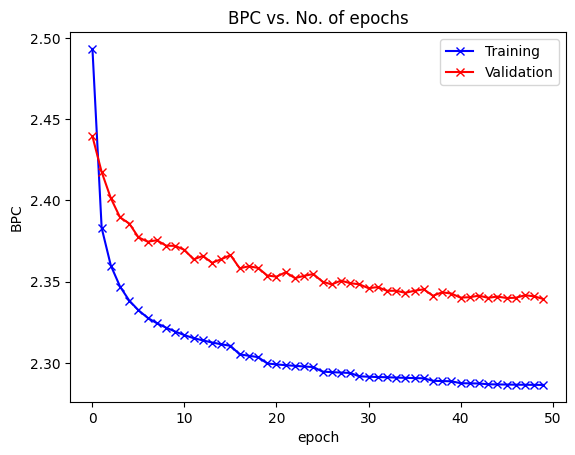

In [15]:
def plot_losses(history):
  train_losses = [x['train_bpc'] for x in history]
  val_losses = [x['val_bpc'] for x in history]
  # test_losses = [x['test_loss'] for x in history]
  plt.plot(train_losses, '-bx')
  plt.plot(val_losses, '-rx')
  # plt.plot(test_losses, '-gx')
  plt.xlabel('epoch')
  plt.ylabel('BPC')
  plt.legend(['Training', 'Validation'])
  plt.title('BPC vs. No. of epochs');

print("RNN")
plot_losses(rnn_history)

RNN


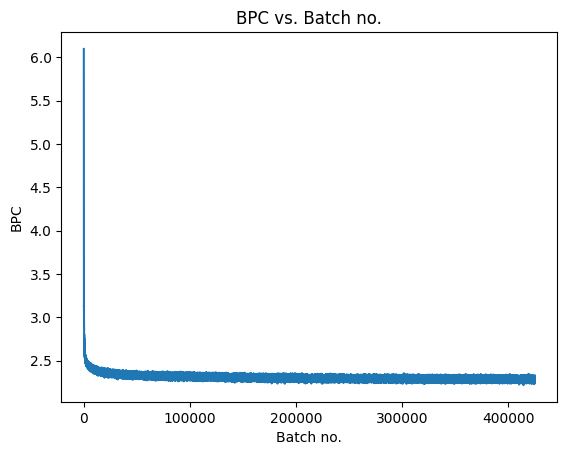

In [16]:
def plot_batch_bpc(history):
  train_bpc = np.concatenate([x.get('batch_train_bpc', []) for x in history])
  plt.plot(train_bpc)
  plt.xlabel('Batch no.')
  plt.ylabel('BPC')
  plt.title('BPC vs. Batch no.');

print("RNN")
plot_batch_bpc(rnn_history)

RNN


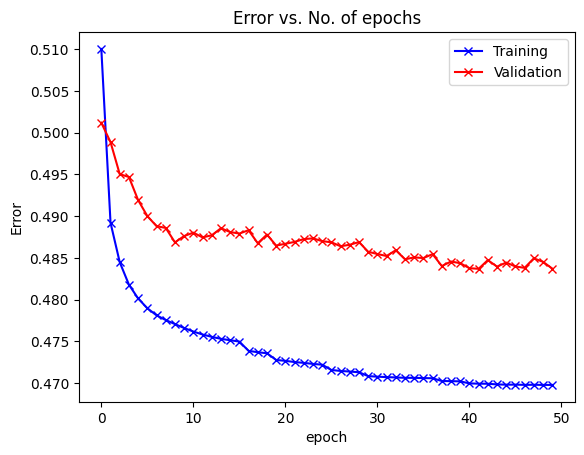

In [17]:

def plot_err(history):
  train_err = [x.get('train_err') for x in history]
  val_err = [x['val_err'] for x in history]
  plt.plot(train_err, '-bx')
  plt.plot(val_err, '-rx')
  plt.xlabel('epoch')
  plt.ylabel('Error')
  plt.legend(['Training', 'Validation'])
  plt.title('Error vs. No. of epochs');

print("RNN")
plot_err(rnn_history)

In [18]:
# weight_path = 'lstm_model.pt'

# checkpoint = torch.load(weight_path)
# lstm_model.load_state_dict(checkpoint, strict=True)

In [19]:
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=config['learning_rate'], weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',           
    factor=0.7,           
    patience=1,
    threshold=0.0001,     
    threshold_mode='rel',
    min_lr=0.0001,        
)

In [20]:
lstm_history = train_model(
    lstm_model, train_dl, valid_dl, "LSTM")

  0%|          | 1/8499 [00:00<44:40,  3.17it/s]

lr:  0.001
BPC:  6.052045822143555
Error: 99.984375 %
Prime text: 
speak of n
------------
Target: 
speak of nothing but despair.
One day too late, I 
------------
Prediction: 
speak of nNnP-moco&k!Bthn3::[K: L
XgoPykkpRvesgxHRsI-yW3JBDP


100%|██████████| 8499/8499 [08:06<00:00, 17.46it/s]


Epoch  1: Learning Rate: 0.001000 train_err: 56.20% val_err: 53.81% Train BPC: 2.804797 Valid BPC:2.664219
Validation loss decreased(inf-->2.664219). Saving model ..
Prime text: 
speak of n
------------
Target: 
speak of nothing but despair.
One day too late, I 
------------
Prediction: 
speak of night of more so heagtters,
You or rown his apted t


100%|██████████| 8499/8499 [08:11<00:00, 17.29it/s]


...

Epoch 48: Learning Rate: 0.000100 train_err: 50.77% val_err: 51.66% Train BPC: 2.506040 Valid BPC:2.534152
Validation loss decreased(2.534483-->2.534152). Saving model ..


100%|██████████| 8499/8499 [10:44<00:00, 13.18it/s]


Epoch 49: Learning Rate: 0.000100 train_err: 50.77% val_err: 51.68% Train BPC: 2.505900 Valid BPC:2.536909
Prime text: 
speak of n
------------
Target: 
speak of nothing but despair.
One day too late, I 
------------
Prediction: 
speak of no morres hands,
Of lad must should of true unto me


100%|██████████| 8499/8499 [10:08<00:00, 13.96it/s]


Epoch 50: Learning Rate: 0.000100 train_err: 50.76% val_err: 51.72% Train BPC: 2.505703 Valid BPC:2.535422
Prime text: 
speak of n
------------
Target: 
speak of nothing but despair.
One day too late, I 
------------
Prediction: 
speak of nor my boot-groness,
Who sheacuse the clook of leas


In [21]:
# torch.save(lstm_model.state_dict(), 'model_weights.pth')
# print("Save model weight successfully.")

LSTM


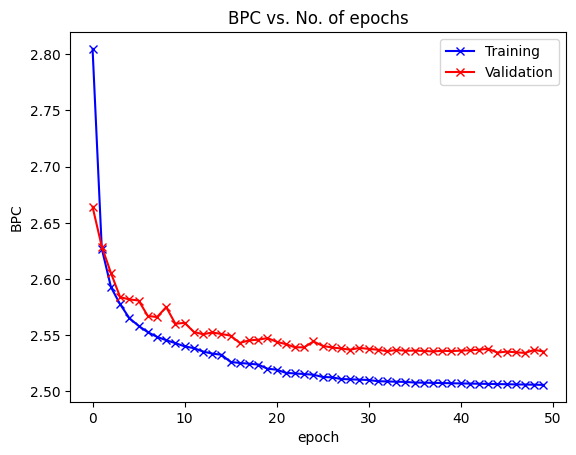

In [22]:
print("LSTM")
plot_losses(lstm_history)

LSTM


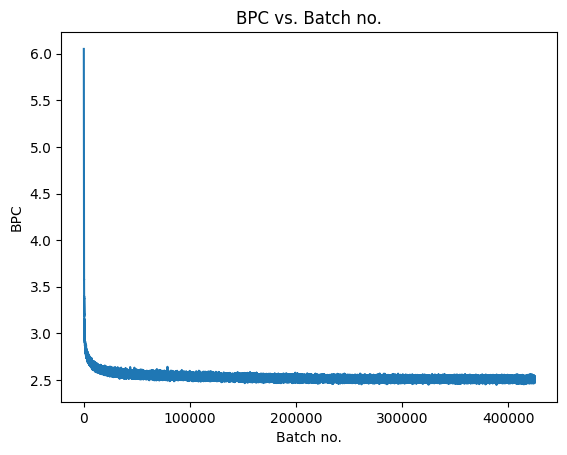

In [23]:
print("LSTM")
plot_batch_bpc(lstm_history)

LSTM


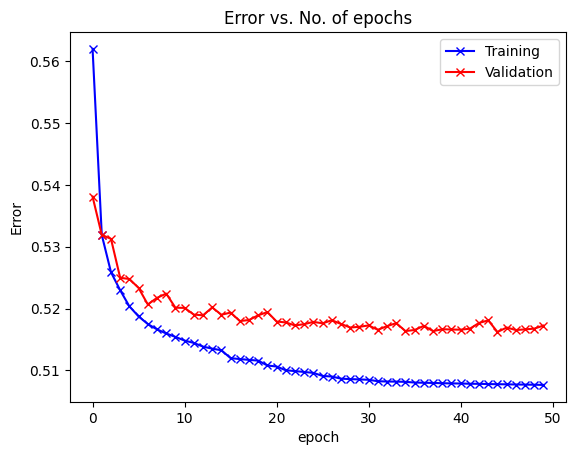

In [24]:
print("LSTM")
plot_err(lstm_history)

RNN


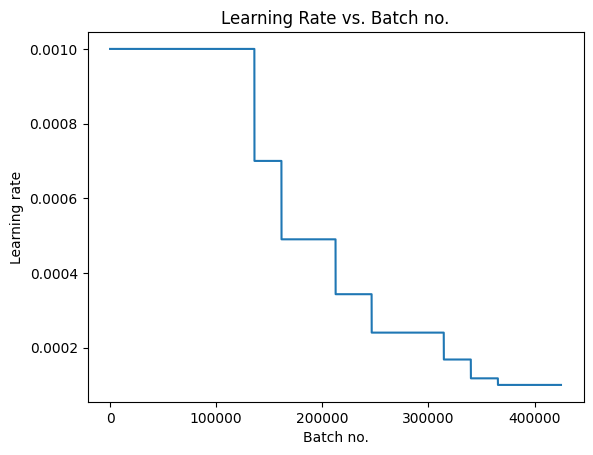

In [25]:
def plot_lrs(history):
  lrs = np.concatenate([x.get('lrs', []) for x in history])
  plt.plot(lrs)
  plt.xlabel('Batch no.')
  plt.ylabel('Learning rate')
  plt.title('Learning Rate vs. Batch no.');

print("RNN")
plot_lrs(rnn_history)

LSTM


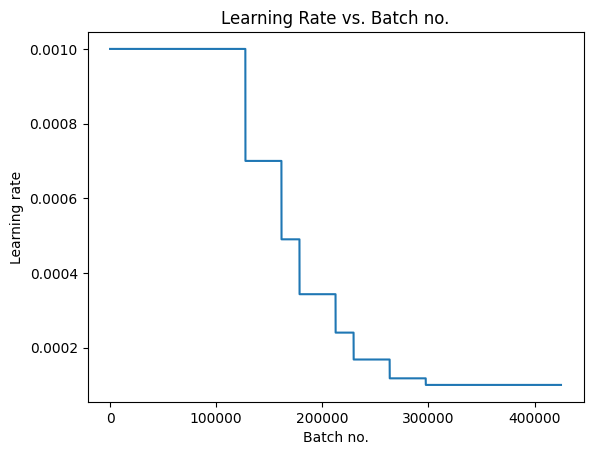

In [26]:
print("LSTM")
plot_lrs(lstm_history)

# Load your model

In [27]:
weight_path = 'rnn_model.pt'

checkpoint = torch.load(weight_path)
rnn_model.eval()
rnn_model.load_state_dict(checkpoint, strict=True)
rnn_model.to(config["device"])

C:\Users\kenla\AppData\Local\Temp\ipykernel_7992\4146559411.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weight_path)


RNNmodel(
  (embedding): Embedding(67, 128)
  (rnn): RNN(128, 128, num_layers=3, batch_first=True)
  (fc): Linear(in_features=128, out_features=67, bias=True)
)

In [28]:
# print(model)

# Testing part

In [29]:
prime_text = "JULIET"
generated_text = generate_text(
    rnn_model, prime_text, vocab_to_int, int_to_vocab, predict_len=500, temperature=0.8
)
print(generated_text)

JULIET:
That weech him he fair'd the braithse. Vost was but shall show
The hole for my life of lubly donesty, a matter to such something of mine,
Did most carty she spore that awayt thou art to every wring.

Fook!
Verefore, and men you doth my let recestate,
That been grace it is in a breth, there it for to show the moner
And cound and her hearts three not to use to the devort of the,
Write his stand for his time wince him.

DOGRO:
The graping sufmither hand again and hearty
That else a from a bewill 
